In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
# Import numerical computation library
import numpy as np

# Import pandas for dataset handling
import pandas as pd

# Import matplotlib for visualization
import matplotlib.pyplot as plt

# Import seaborn for advanced visualization
import seaborn as sns

# Ignore warning messages
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import files
df = files.upload()

Saving ML-CaseStudy3-Dataset.csv to ML-CaseStudy3-Dataset.csv


In [ ]:
#Read exel file
df = pd.read_csv('ML-CaseStudy3-Dataset.csv')
# Display first  rows
df.head()

,case_id,country,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,symptoms,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
0,HV2026_00001,Canada,Lake Rickyside,24-11-2025,Sin Nombre,Rodent-to-Human,Agricultural Exposure,26,Male,"Headache, Vomiting, Fever",Yes,No,22.0,27.0,78.9,7,1,538,67
1,HV2026_00002,Bolivia,East Crystal,22-04-2025,Sin Nombre,Human-to-Human,Home Infestation,41,Female,"Fever, Muscle Pain, Fatigue",Yes,No,41.0,23.2,70.9,3,13,5624,162
2,HV2026_00003,Chile,Rossmouth,21-03-2025,Seoul,Human-to-Human,Home Infestation,39,Female,"Fever, Muscle Pain, Fatigue",No,No,31.0,22.6,38.5,8,17,2095,213
3,HV2026_00004,Argentina,West Ryan,10-02-2025,Sin Nombre,Human-to-Human,Rodent Exposure,49,Male,"Fever, Muscle Pain, Fatigue",No,No,11.0,22.6,87.0,7,8,7478,206
4,HV2026_00005,Chile,Mariaberg,25-03-2025,Dobrava,Rodent-to-Human,Home Infestation,59,Male,"Fever, Cough, Headache",No,No,24.0,33.5,36.2,8,12,4472,132


In [ ]:
# Check dataset shape
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:\n", df.columns)

# Display data types
print("\nData Types:\n")
print(df.dtypes)

Dataset Shape: (2000, 19)

Column Names:
 Index(['case_id', 'country', 'region', 'report_date', 'virus_strain',
       'transmission_type', 'exposure_source', 'patient_age', 'gender',
       'symptoms', 'hospitalization', 'fatality', 'recovery_days',
       'temperature_celsius', 'humidity_percent', 'rodent_presence_index',
       'quarantine_days', 'population_density', 'air_quality_index'],
      dtype='object')

Data Types:

case_id                   object
country                   object
region                    object
report_date               object
virus_strain              object
transmission_type         object
exposure_source           object
patient_age                int64
gender                    object
symptoms                  object
hospitalization           object
fatality                  object
recovery_days            float64
temperature_celsius      float64
humidity_percent         float64
rodent_presence_index      int64
quarantine_days            int64
populat

In [ ]:
print(df.isnull().sum())

case_id                    0
country                    0
region                     0
report_date                0
virus_strain               0
transmission_type          0
exposure_source            0
patient_age                0
gender                     0
symptoms                   0
hospitalization            0
fatality                   0
recovery_days            155
temperature_celsius        0
humidity_percent           0
rodent_presence_index      0
quarantine_days            0
population_density         0
air_quality_index          0
dtype: int64


In [ ]:
df.describe()

,patient_age,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density,air_quality_index
count,2000.000000,1845.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,45.196000,26.293225,24.174850,64.623400,5.494500,10.551500,4968.62350,159.701000
std,19.115001,11.273430,5.981896,17.466002,2.868115,6.369037,2961.87065,81.034152
min,12.000000,7.000000,4.600000,35.000000,1.000000,0.000000,54.00000,20.000000
25%,29.000000,16.000000,20.200000,49.500000,3.000000,5.000000,2341.25000,89.000000
50%,46.000000,27.000000,24.200000,64.550000,5.000000,11.000000,4952.50000,162.000000
75%,62.000000,36.000000,28.000000,79.825000,8.000000,16.000000,7648.75000,231.250000
max,78.000000,45.000000,47.600000,95.000000,10.000000,21.000000,9999.00000,300.000000


In [ ]:
df.dropna(inplace=True)

In [ ]:
print(df.isnull().sum())

case_id                  0
country                  0
region                   0
report_date              0
virus_strain             0
transmission_type        0
exposure_source          0
patient_age              0
gender                   0
symptoms                 0
hospitalization          0
fatality                 0
recovery_days            0
temperature_celsius      0
humidity_percent         0
rodent_presence_index    0
quarantine_days          0
population_density       0
air_quality_index        0
dtype: int64


In [ ]:
# Selecting numerical features only
X = df.drop(['case_id', 'country', 'symptoms', 'air_quality_index'], axis=1)

# Display first 5 rows
X.head()

,region,report_date,virus_strain,transmission_type,exposure_source,patient_age,gender,hospitalization,fatality,recovery_days,temperature_celsius,humidity_percent,rodent_presence_index,quarantine_days,population_density
0,Lake Rickyside,24-11-2025,Sin Nombre,Rodent-to-Human,Agricultural Exposure,26,Male,Yes,No,22.0,27.0,78.9,7,1,538
1,East Crystal,22-04-2025,Sin Nombre,Human-to-Human,Home Infestation,41,Female,Yes,No,41.0,23.2,70.9,3,13,5624
2,Rossmouth,21-03-2025,Seoul,Human-to-Human,Home Infestation,39,Female,No,No,31.0,22.6,38.5,8,17,2095
3,West Ryan,10-02-2025,Sin Nombre,Human-to-Human,Rodent Exposure,49,Male,No,No,11.0,22.6,87.0,7,8,7478
4,Mariaberg,25-03-2025,Dobrava,Rodent-to-Human,Home Infestation,59,Male,No,No,24.0,33.5,36.2,8,12,4472


In [ ]:
# Import StandardScaler
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd

le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
X = df[['country', 'region', 'report_date', 'virus_strain',
           'transmission_type', 'exposure_source']]
y = df['case_id']

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(1845, 18)


In [ ]:
# Import KMeans
from sklearn.cluster import KMeans

# Create empty list for WCSS
wcss = []

# Run loop for different k values
for i in range(1, 11):

    # Create KMeans model
    kmeans = KMeans(n_clusters=i, random_state=42)

    # Fit model
    kmeans.fit(X_scaled)

    # Append inertia value
    wcss.append(kmeans.inertia_)

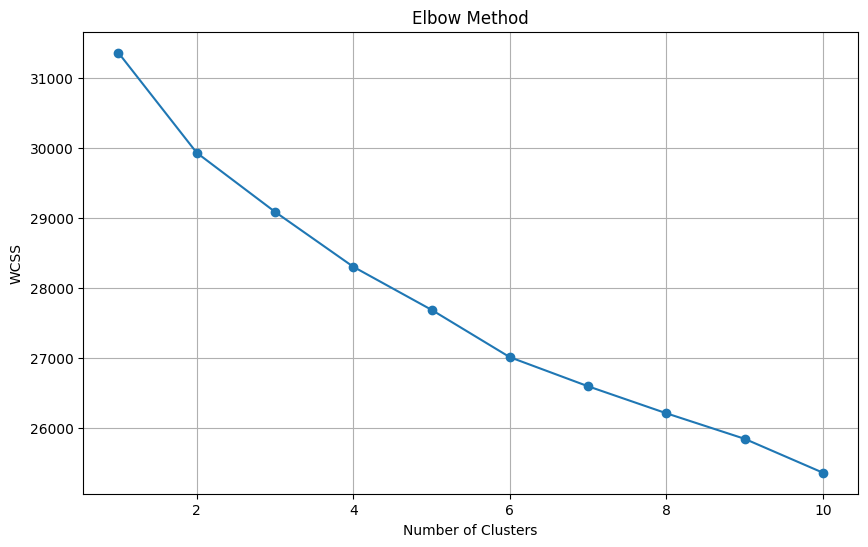

In [ ]:
# Plot elbow graph
plt.figure(figsize=(10,6))

plt.plot(range(1,11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [ ]:
# Create KMeans model
kmeans = KMeans(n_clusters=4, random_state=42)

# Fit and predict clusters
clusters = kmeans.fit_predict(X_scaled)

# Add cluster column into dataset
df['Cluster'] = clusters

In [ ]:
# Import PCA
from sklearn.decomposition import PCA

# Create PCA object
pca = PCA(n_components=2)

# Transform scaled data
pca_components = pca.fit_transform(X_scaled)

# Create new dataframe
pca_df = pd.DataFrame(data=pca_components, columns=['PCA1', 'PCA2'])

# Add cluster column
pca_df['Cluster'] = clusters

In [ ]:
# Plot clusters
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='viridis',
    data=pca_df,
    s=100
)

plt.title('K-Means Clustering Visualization')

plt.show()

NameError: name 'plt' is not defined

In [ ]:
# Cluster-wise average values
cluster_mean = df.groupby('Cluster').mean(numeric_only=True)

# Display analysis
print(cluster_mean)

            case_id   country       region  report_date  virus_strain  \
Cluster                                                                 
0        907.445455  4.311364  1119.159091   258.229545      2.568182   
1        926.565875  4.952484   878.408207   236.120950      1.427646   
2        958.053305  3.818763   876.897655   268.087420      1.686567   
3        895.321353  4.665962   585.737844   216.084567      2.545455   

         transmission_type  exposure_source  patient_age    gender  symptoms  \
Cluster                                                                        
0                 0.509091         3.254545    54.690909  0.640909  2.954545   
1                 0.656587         2.676026    38.287257  0.794816  1.583153   
2                 0.437100         1.933902    31.061834  0.255864  2.223881   
3                 0.397463         2.289641    57.972516  0.329810  1.295983   

         hospitalization  fatality  recovery_days  temperature_celsius  \
Cluste

In this experiment, three classification algorithms
were implemented - Decision Tree, Random Forest, and KNN.

Decision Tree creates a tree-like model for decisions.
Random Forest combines multiple decision trees for
better accuracy.
KNN classifies data based on nearest neighbors.

The models were trained on 80% data and tested on 20% data.

Decision Tree Accuracy: _
Random Forest Accuracy: _
KNN Accuracy: _

Among all three models, Random Forest gave the
highest accuracy, making it the best model for
this classification task.